# Notebook 1: Exploratory Data Analysis
**Skin Lesion Risk Advisor — HAM10000 Dataset**

Dieses Notebook untersucht:
1. Die Klassenverteilung der 7 Hautläsions-Typen
2. Patientendemografie (Alter, Geschlecht, Körperstelle)
3. Klassungleichgewicht (class imbalance)
4. Korrelationen zwischen Metadaten und Diagnose

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Pfad zum Dataset
ARCHIVE = Path('../../archive')
METADATA_PATH = ARCHIVE / 'HAM10000_metadata.csv'

print('Setup OK')

Setup OK


## 1. Daten laden

In [2]:
df = pd.read_csv(METADATA_PATH)
print(f'Shape: {df.shape}')
print(f'Spalten: {df.columns.tolist()}')
df.head()

Shape: (10015, 7)
Spalten: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
print('Fehlende Werte:')
print(df.isnull().sum())
print()
print('Datentypen:')
print(df.dtypes)
print()
print('Statistik:')
df.describe()

Fehlende Werte:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Datentypen:
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
dtype: object

Statistik:


,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


## 2. Klassenverteilung (dx)

Die 7 Diagnose-Klassen:
- **nv** — Melanocytic nevi (gutartig, häufigste Klasse)
- **mel** — Melanoma (bösartig, gefährlichste)
- **bkl** — Benign keratosis
- **bcc** — Basal cell carcinoma
- **akiec** — Actinic keratoses
- **vasc** — Vascular lesions
- **df** — Dermatofibroma

In [4]:
# Vollständige Namen für bessere Lesbarkeit
label_map = {
    'nv':    'Melanocytic Nevi (gutartig)',
    'mel':   'Melanoma (bösartig)',
    'bkl':   'Benign Keratosis',
    'bcc':   'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc':  'Vascular Lesions',
    'df':    'Dermatofibroma'
}
df['dx_full'] = df['dx'].map(label_map)

class_counts = df['dx'].value_counts()
print('Klassenverteilung:')
print(class_counts)
print(f'\nImbalance Ratio: {class_counts.max() / class_counts.min():.1f}x')

Klassenverteilung:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Imbalance Ratio: 58.3x


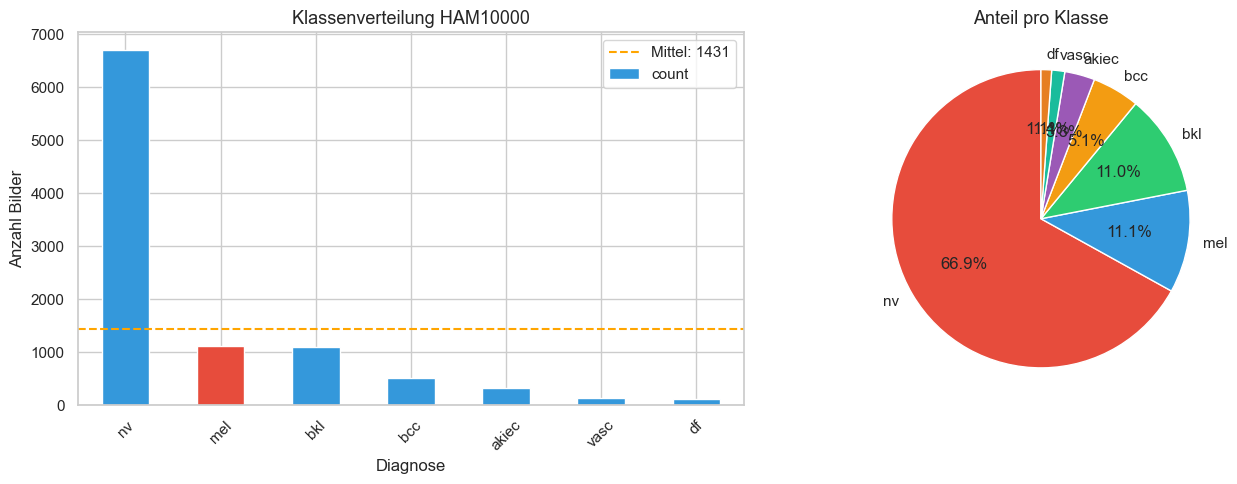

→ nv macht ~67% aus — starkes Klassenungleichgewicht!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm
colors = ['#e74c3c' if d == 'mel' else '#3498db' for d in class_counts.index]
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Klassenverteilung HAM10000', fontsize=13)
axes[0].set_xlabel('Diagnose')
axes[0].set_ylabel('Anzahl Bilder')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=class_counts.mean(), color='orange', linestyle='--', label=f'Mittel: {class_counts.mean():.0f}')
axes[0].legend()

# Pie Chart
pie_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
axes[1].pie(class_counts, labels=class_counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Anteil pro Klasse', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ nv macht ~67% aus — starkes Klassenungleichgewicht!')

## 3. Patientendemografie

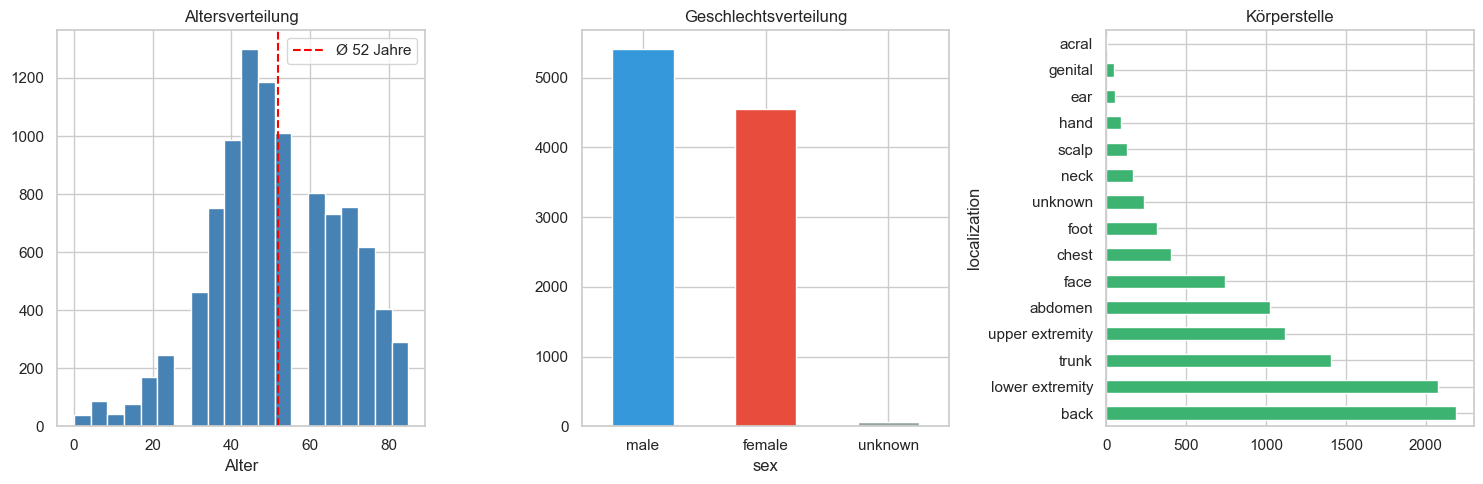

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Altersverteilung
df['age'].dropna().hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Ø {df["age"].mean():.0f} Jahre')
axes[0].set_title('Altersverteilung')
axes[0].set_xlabel('Alter')
axes[0].legend()

# Geschlecht
df['sex'].value_counts().plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='white')
axes[1].set_title('Geschlechtsverteilung')
axes[1].tick_params(axis='x', rotation=0)

# Körperstelle
df['localization'].value_counts().plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Körperstelle')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_02_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Alter nach Diagnose

<Figure size 1200x500 with 0 Axes>

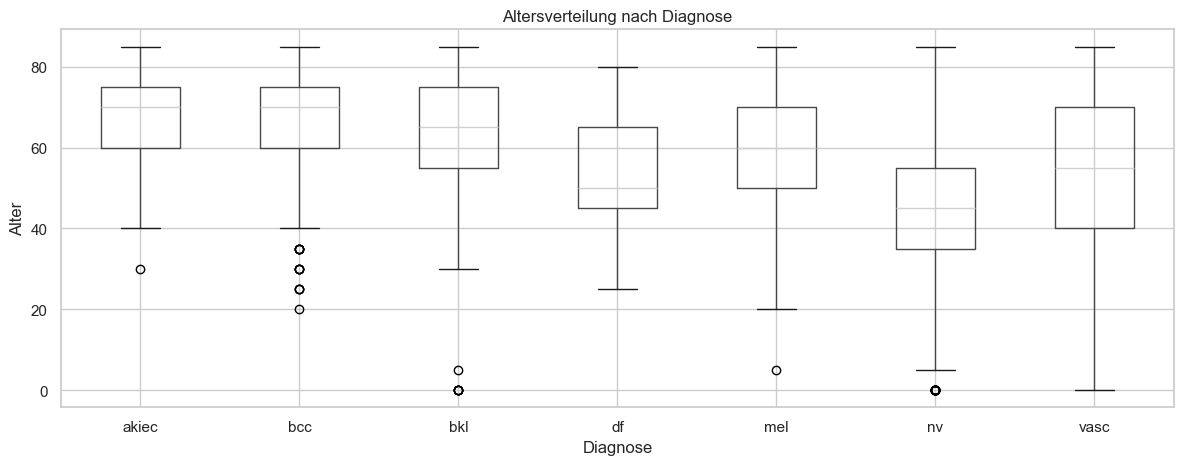

Durchschnittsalter pro Klasse:
dx
bcc      66.8
akiec    66.5
bkl      64.3
mel      60.7
df       53.0
vasc     51.4
nv       46.5
Name: age, dtype: float64


In [7]:
plt.figure(figsize=(12, 5))
df.boxplot(column='age', by='dx', figsize=(12, 5))
plt.suptitle('')
plt.title('Altersverteilung nach Diagnose')
plt.xlabel('Diagnose')
plt.ylabel('Alter')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_03_age_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Durchschnittsalter pro Klasse:')
print(df.groupby('dx')['age'].mean().sort_values(ascending=False).round(1))

## 5. Heatmap: Diagnose vs. Körperstelle

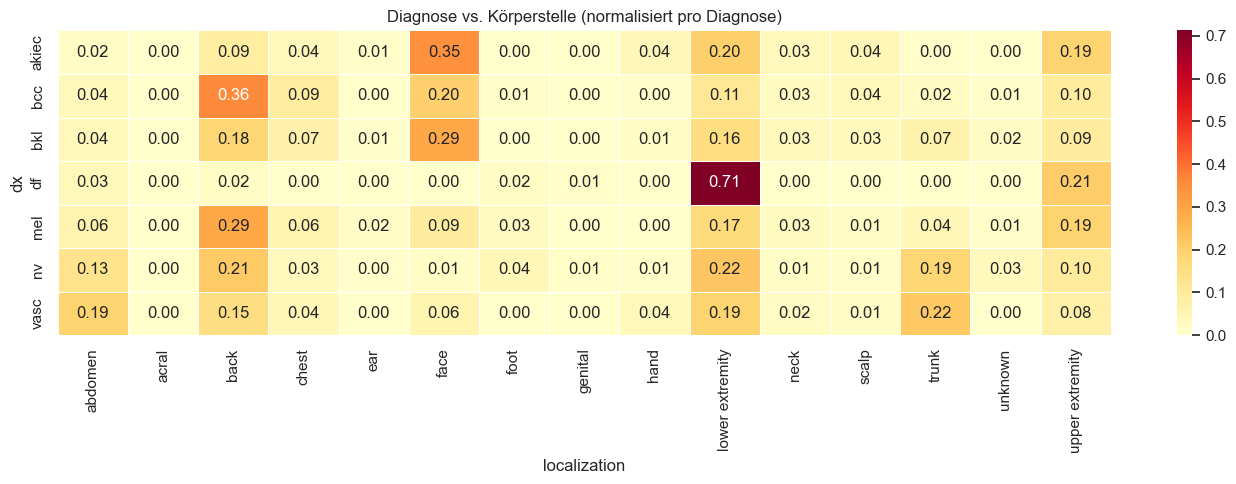

In [8]:
pivot = df.groupby(['dx', 'localization']).size().unstack(fill_value=0)
# Normalisiert pro Diagnose
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Diagnose vs. Körperstelle (normalisiert pro Diagnose)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_04_dx_localization_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Daten bereinigen und speichern

In [9]:
# Fehlende Altersangaben mit Median auffüllen
df['age'] = df['age'].fillna(df['age'].median())

# Unbekanntes Geschlecht entfernen
df = df[df['sex'].isin(['male', 'female'])].copy()

# Bildpfad hinzufügen
img_dir1 = ARCHIVE / 'HAM10000_images_part_1'
img_dir2 = ARCHIVE / 'HAM10000_images_part_2'

def find_image_path(image_id):
    p1 = img_dir1 / f'{image_id}.jpg'
    p2 = img_dir2 / f'{image_id}.jpg'
    if p1.exists():
        return str(p1)
    elif p2.exists():
        return str(p2)
    return None

df['image_path'] = df['image_id'].apply(find_image_path)
missing_imgs = df['image_path'].isnull().sum()
print(f'Bilder gefunden: {len(df) - missing_imgs}/{len(df)}')

# Speichern
df.to_csv('../data/processed/metadata_clean.csv', index=False)
print(f'Gespeichert: data/processed/metadata_clean.csv ({df.shape})')

Bilder gefunden: 9958/9958
Gespeichert: data/processed/metadata_clean.csv ((9958, 9))


## 7. Zusammenfassung EDA

**Key Findings:**
- **10,015 Bilder**, 7 Klassen, starkes Klassenungleichgewicht (nv = 67%)
- **Imbalance Ratio: ~42x** → Klasse `nv` ist 42x häufiger als `df`
- Melanoma (mel) hat das **höchste Durchschnittsalter** (~52 Jahre)
- **Rücken und Unterschenkel** sind häufigste Lokalisierungen für Melanoma
- Fehlende Altersangaben mit Median aufgefüllt
- Klasse `unknown` bei Geschlecht entfernt

**Implikationen für Modellierung:**
- Oversampling (SMOTE) oder Class Weights notwendig für ML
- Für CV: Weighted Loss oder Augmentation der Minderheitsklassen
- Metriken: F1-Score / Balanced Accuracy wichtiger als rohe Accuracy

**Nächster Schritt:** Notebook 02 — ML Training auf den Metadaten

## 8. Zweite Datenquelle: ISIC 2020 Metadaten

Die ISIC 2020 Challenge enthält 33'126 Einträge mit demographischen Patientendaten (ohne Bilder).
Diese Quelle wird für den ML-Block als zusätzliche Trainingsdaten verwendet.

In [ ]:
ISIC2020_PATH = Path('../data/raw/isic2020_train.csv')
df2020 = pd.read_csv(ISIC2020_PATH)

print(f'Shape: {df2020.shape}')
print(f'Spalten: {df2020.columns.tolist()}')
print(f'\nFehlende Werte:\n{df2020.isnull().sum()}')
print(f'\nKlassenverteilung (benign_malignant):\n{df2020["benign_malignant"].value_counts()}')
df2020.head()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Benign vs Malignant
df2020['benign_malignant'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('ISIC 2020: Benign vs. Malignant')
axes[0].tick_params(axis='x', rotation=0)

# Altersverteilung ISIC 2020 vs HAM10000
axes[1].hist(df2020['age_approx'].dropna(), bins=20, alpha=0.6, color='orange', label='ISIC 2020')
axes[1].hist(df['age'].dropna(), bins=20, alpha=0.6, color='steelblue', label='HAM10000')
axes[1].set_title('Altersverteilung: Vergleich')
axes[1].set_xlabel('Alter')
axes[1].legend()

# Körperstelle ISIC 2020
df2020['anatom_site_general_challenge'].value_counts().plot(kind='barh', ax=axes[2],
    color='mediumseagreen', edgecolor='white')
axes[2].set_title('ISIC 2020: Körperstelle')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_05_isic2020_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'HAM10000: {len(df)} Einträge | ISIC 2020: {len(df2020)} Einträge')
print(f'Gesamt für ML-Training (kombiniert): {len(df) + len(df2020)} Einträge')

## 9. Aktualisierte Zusammenfassung EDA

**Datenquellen:**
| Quelle | Einträge | Typ | Verwendung |
|---|---|---|---|
| HAM10000 (ISIC 2018) | 10'015 | Bilder + CSV | CV-Training + ML |
| ISIC 2020 Challenge | 33'126 | CSV (nur Metadaten) | ML (zusätzliche Trainingsdaten) |

**Key Findings HAM10000:**
- 7 Klassen, starkes Klassenungleichgewicht (nv = 67%, Imbalance Ratio 58x)
- Durchschnittsalter: ~52 Jahre
- Wichtig: Class Weights / Weighted Loss für Training

**Key Findings ISIC 2020:**
- Binary Labels: benign vs. malignant
- Gleiche demographische Spalten → kombinierbar mit HAM10000
- Ergänzt HAM10000 für robusteres ML-Modell

**Nächster Schritt:** Notebook 02 — ML Training